In [1]:
%load_ext autoreload
%autoreload 2

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns 
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from style import set_style, lr_labels
set_style()

PLOT_DIR = Path('plots/cifar10_labelreg')
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {PLOT_DIR.resolve()}")

Plots will be saved to: /Users/sambt/iaifi/sv3/analysis/plots/cifar10_labelreg


In [8]:
# Load JSONL results
from style import load_results, load_results_jsonl

df = load_results("cifar10_resnet_scan_labelRegression")

def is_bad(row):
    if np.isnan(row['losses']['val'][-1]):
        return True
    return False
df['is_bad'] = df.apply(is_bad, axis=1)
df = df[~df['is_bad']]
print(f"After removing bad runs: {len(df)} experiment runs")

Loaded 88 runs from ../experiment_results/cifar10_resnet_scan_labelRegression/ (directory format)
After removing bad runs: 87 experiment runs


In [5]:
for opt in df.optimizer.unique():
    for seed in df.model_seed.unique():
        N = len(df[(df.model_seed == seed) & (df.optimizer == opt)])
        print(f"Seed {seed}: {N} {opt} runs")

Seed 47612: 4 Adam runs
Seed 47612: 4 RMSprop runs
Seed 47612: 3 SGD runs
Seed 47612: 48 LBFGS runs
Seed 47612: 1 PolyakSGD runs
Seed 47612: 27 SVD runs


In [15]:
#SEED_SEL = 7310
BASELINE_OPT = ['SGD','PolyakSGD','RMSprop','Adam','LBFGS']#,'JD_UPGrad','HIG']

In [11]:
# Helper functions
def get_final_loss(row, loss_type='val'):
    losses = row['losses'][loss_type]
    # Return last non-NaN value (handles instability)
    for val in reversed(losses):
        if val is not None and not (isinstance(val, float) and np.isnan(val)):
            return val
    return np.nan

def get_loss_curve(row, loss_type='val'):
    return np.array(row['losses'][loss_type])

def get_acc_curve(row, acc_type='val_acc'):
    return np.array(row['losses'].get(acc_type, []))

def sliding_average(data, window=10):
    return np.convolve(data, np.ones(window)/window, mode='valid')

# Add derived columns once on the full df
df['final_val_loss'] = df.apply(lambda r: get_final_loss(r, 'val'), axis=1)
df['final_train_loss'] = df.apply(lambda r: get_final_loss(r, 'train'), axis=1)
df['final_val_acc'] = df.apply(lambda r: r['losses'].get('val_acc', [np.nan])[-1], axis=1)
df['final_train_acc'] = df.apply(lambda r: r['losses'].get('train_acc', [np.nan])[-1], axis=1)
df['total_time'] = df['losses'].apply(lambda l: l.get('total_time', np.nan))
df['avg_epoch_time'] = df['losses'].apply(lambda l: l.get('avg_epoch_time', np.nan))
df['avg_batch_time_train'] = df['losses'].apply(lambda l: l.get('avg_batch_time_train', np.nan))

def _time_excl_first(row):
    et = row['losses'].get('epoch_times', [])
    return sum(et[1:]) if len(et) > 1 else np.nan

def _avg_batch_excl_first(row):
    bt = row['losses'].get('batch_times_train', [])
    return np.mean(bt[1:]) if len(bt) > 1 else np.nan

df['time_excl_first_epoch'] = df.apply(_time_excl_first, axis=1)
df['avg_batch_time_excl_first'] = df.apply(_avg_batch_excl_first, axis=1)

batch_sizes = sorted(df['batch_size'].unique())
print(f"Available batch sizes: {batch_sizes}")

df_svd = df[(df['optimizer'] == 'SVD')].copy()
df_baseline = df[df['optimizer'] != 'SVD'].copy()

bs = sorted(df['batch_size'].unique())[0] 
batch_sizes = sorted(df['batch_size'].unique())
baseline_optimizers = sorted(df_baseline['optimizer'].unique().tolist())
k_fractions = sorted(df_svd['k_fraction'].dropna().unique())
svd_lrs = sorted(df_svd['lr'].unique())
svd_rtols = sorted(df_svd['rtol'].dropna().unique())

print(f"\nSVD: {len(df_svd)} runs")
print(f"  k_fractions: {k_fractions}")
print(f"  lrs: {svd_lrs}")
print(f"  rtols: {svd_rtols}")
print(f"\nBaseline: {len(df_baseline)} runs")
print(f"  Optimizers: {baseline_optimizers}")
print(f"  lrs: {sorted([l for l in df_baseline['lr'].unique() if l is not None])}")

Available batch sizes: [np.int64(128)]

SVD: 27 runs
  k_fractions: [np.float64(0.5), np.float64(0.75), np.float64(1.0)]
  lrs: [np.float64(0.1), np.float64(0.5), np.float64(1.0)]
  rtols: [np.float64(0.0001), np.float64(0.001), np.float64(0.01)]

Baseline: 60 runs
  Optimizers: ['Adam', 'LBFGS', 'PolyakSGD', 'RMSprop', 'SGD']
  lrs: [np.float64(0.0001), np.float64(0.001), np.float64(0.01), np.float64(0.1), np.float64(0.5), np.float64(1.0), np.float64(nan)]


### quick check

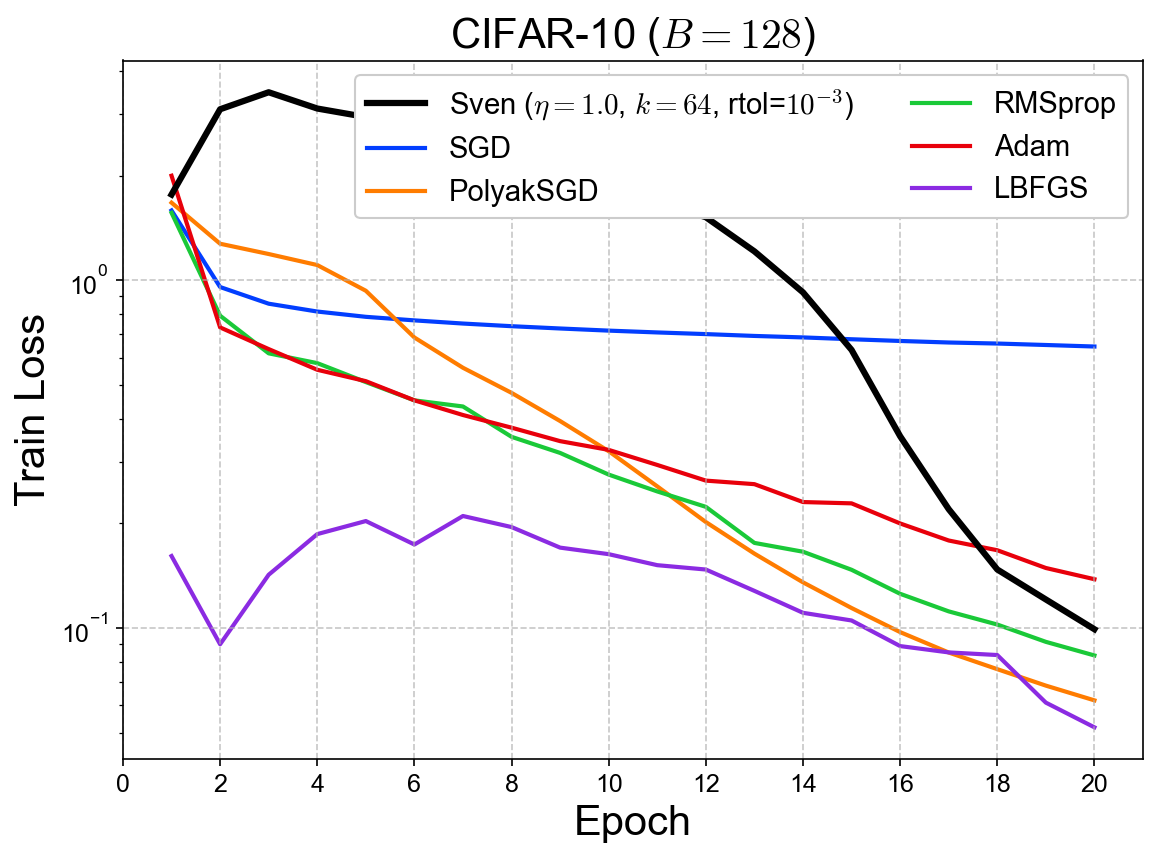

In [16]:
colors = sns.color_palette("bright", n_colors=len(baseline_optimizers))

fig, ax = plt.subplots(figsize=(8, 6))
legend_labels = []

# Best SVD no rmsprop
best_svd_row_noRMSprop = df_svd.loc[df_svd.final_val_loss.sort_values().index[0]]
train_curve_noRMSprop = get_loss_curve(best_svd_row_noRMSprop, 'train')
n_epochs = len(train_curve_noRMSprop)
epochs_train = np.arange(n_epochs)+1
ax.plot(epochs_train, train_curve_noRMSprop, color='k', linestyle='-', linewidth=3, label=f"Sven ($\eta={best_svd_row_noRMSprop['lr']}$, $k={int(best_svd_row_noRMSprop['k'])}$, rtol=${lr_labels[best_svd_row_noRMSprop['rtol']]}$)",zorder=2)

# Best baselines
for i, opt in enumerate(BASELINE_OPT):
    opt_df = df_baseline[(df_baseline['optimizer'] == opt) & (df_baseline['batch_size'] == bs)]
    best_row = df.loc[opt_df['final_val_loss'].idxmin()]
    #label = f"{opt} ($\eta={lr_labels[best_row['lr']]}$)" if opt != "PolyakSGD" else f"{opt}"
    label = f"{opt}"
    ax.plot(epochs_train, get_loss_curve(best_row, 'train'), color=colors[i], linewidth=2, label=label,zorder=1)

ax.set_xlabel('Epoch')
ax.set_ylabel('Train Loss')
ax.set_yscale('log')
plt.legend(ncol=2,loc='upper right',frameon=True,framealpha=1)
ax.set_title(f"CIFAR-10 ($B = {bs}$)")
#plt.ylim([2e-2,1.0])
plt.xlim(0,n_epochs+1)
plt.xticks(np.arange(0, n_epochs+1, max(1, n_epochs//10)))
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'train_loss_best.pdf')
plt.show()

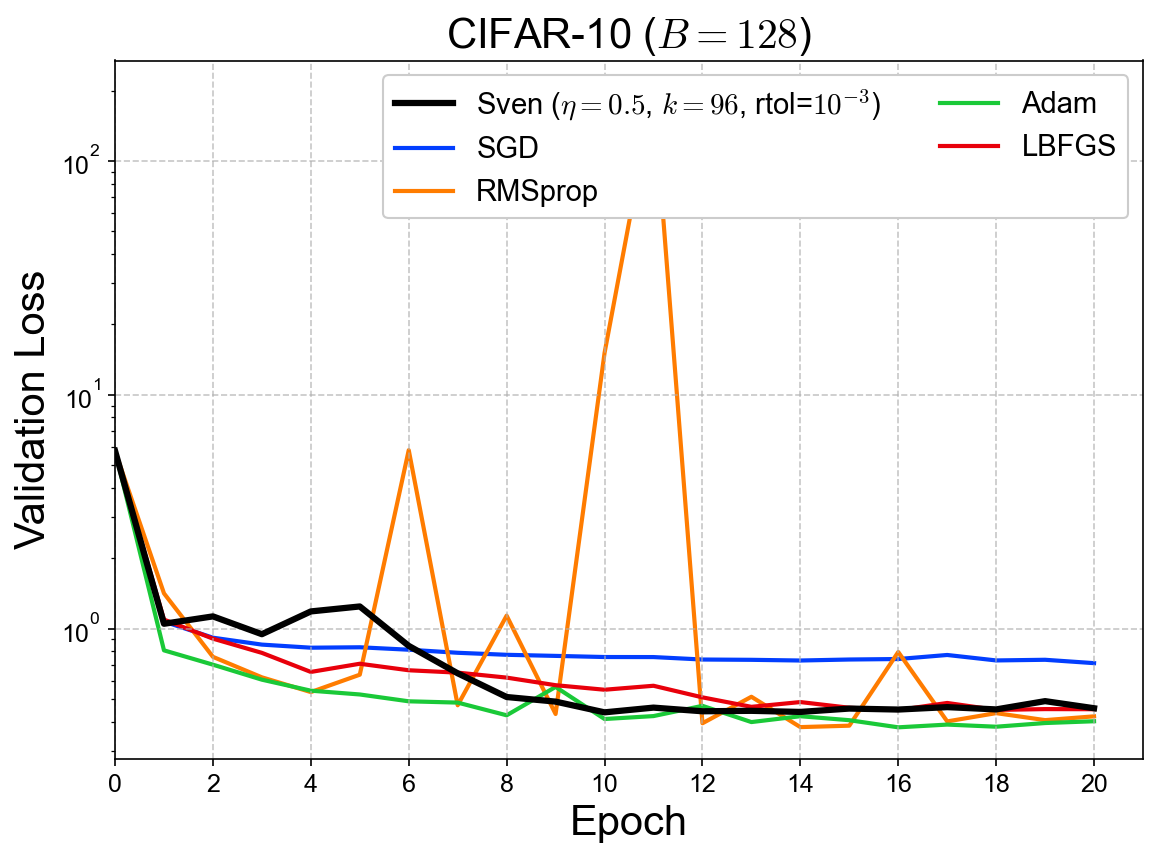

In [18]:
colors = sns.color_palette("bright", n_colors=len(baseline_optimizers))

fig, ax = plt.subplots(figsize=(8, 6))
legend_labels = []

# Best SVD no rmsprop
#best_svd_row_noRMSprop = df_svd.loc[df_svd[df_svd['batch_size'] == bs]['final_val_loss'].idxmin()]
best_svd_row_noRMSprop = df_svd.loc[df_svd.final_val_loss.sort_values().index[3]]
train_curve_noRMSprop = get_loss_curve(best_svd_row_noRMSprop, 'val')
n_epochs = len(train_curve_noRMSprop)
epochs_train = np.arange(n_epochs)
ax.plot(epochs_train, train_curve_noRMSprop, color='k', linestyle='-', linewidth=3, label=f"Sven ($\eta={best_svd_row_noRMSprop['lr']}$, $k={int(best_svd_row_noRMSprop['k'])}$, rtol=${lr_labels[best_svd_row_noRMSprop['rtol']]}$)",zorder=2)

# Best baselines
for i, opt in enumerate(['SGD','RMSprop','Adam','LBFGS']):
    opt_df = df_baseline[(df_baseline['optimizer'] == opt) & (df_baseline['batch_size'] == bs)]
    best_row = df.loc[opt_df['final_val_loss'].idxmin()]
    #label=f"{opt} ($\eta={lr_labels[best_row['lr']]}$)" if opt != "PolyakSGD" else f"{opt}"
    label= f"{opt}"
    ax.plot(epochs_train, get_loss_curve(best_row, 'val'), color=colors[i], linewidth=2, label=label,zorder=1)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_yscale('log')
plt.legend(ncol=2,loc='upper right',frameon=True,framealpha=1,fontsize=14)
ax.set_title(f"CIFAR-10 ($B = {bs}$)")
#plt.ylim([None,1])
plt.xlim(0,n_epochs)
plt.xticks(np.arange(0, n_epochs+1, max(1, n_epochs//10)))
plt.grid(axis='both', linestyle='--', alpha=0.7,zorder=0)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'val_loss_best.pdf')
plt.show()

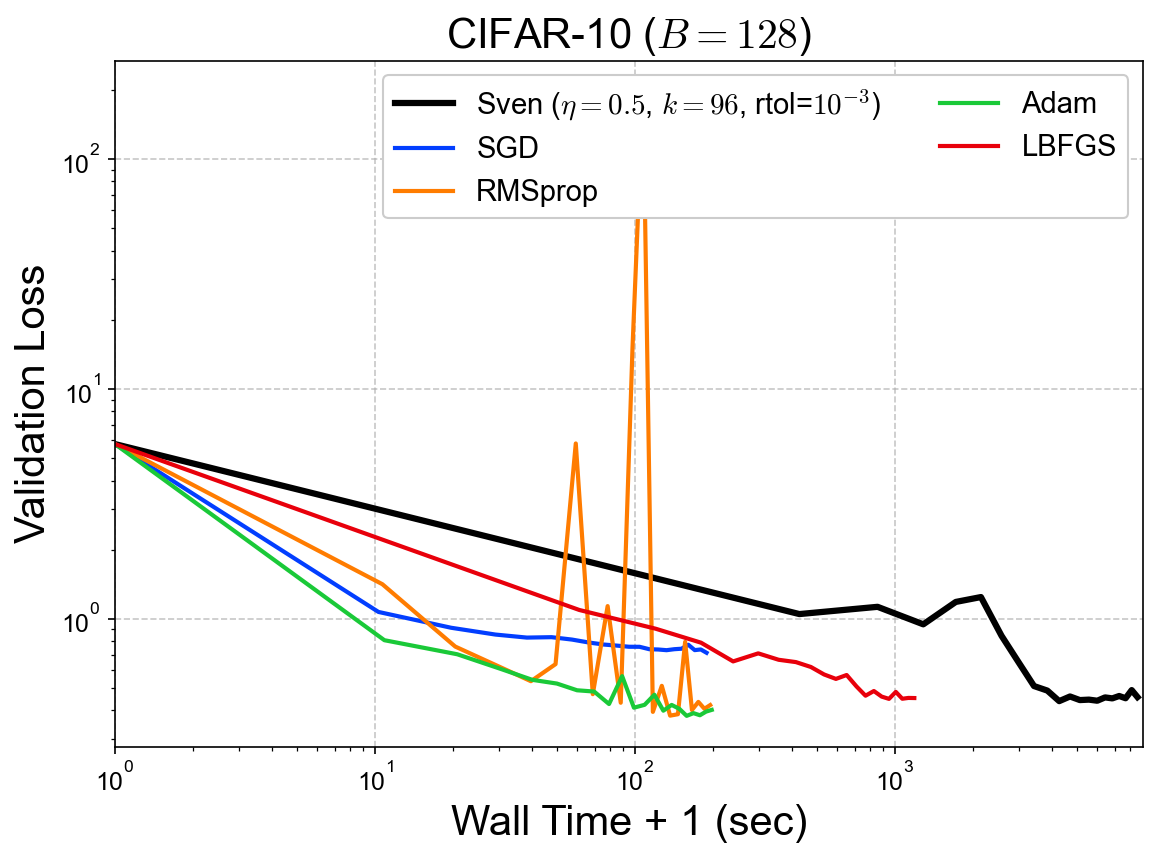

In [21]:
colors = sns.color_palette("bright", n_colors=len(baseline_optimizers))

fig, ax = plt.subplots(figsize=(8, 6))
legend_labels = []

# Best SVD
#best_svd_row = df_svd.loc[df_svd[df_svd['batch_size'] == bs]['final_val_loss'].idxmin()]
best_svd_row = df_svd.loc[df_svd.final_val_loss.sort_values().index[3]]
train_curve = get_loss_curve(best_svd_row, 'val')
wall_times = get_loss_curve(best_svd_row, 'epoch_times')
wall_times = np.concatenate(([1], wall_times))  # Add 0 at start to align with epochs
t = np.cumsum(wall_times)
ax.plot(t, train_curve, color='k', linewidth=3, label=f"Sven ($\eta={best_svd_row['lr']}$, $k={int(best_svd_row['k'])}$, rtol=${lr_labels[best_svd_row['rtol']]}$)")

# Best baselines
for i, opt in enumerate(['SGD','RMSprop','Adam','LBFGS']):
    opt_df = df_baseline[(df_baseline['optimizer'] == opt) & (df_baseline['batch_size'] == bs)]
    best_row = df.loc[opt_df['final_val_loss'].idxmin()]
    t = get_loss_curve(best_row, 'epoch_times')
    t = np.concatenate(([1], t))  # Add 0 at start to align with epochs
    t = np.cumsum(t)
    #label=f"{opt} ($\eta={lr_labels[best_row['lr']]}$)"
    label = f"{opt}"
    ax.plot(t, get_loss_curve(best_row, 'val'), color=colors[i], linewidth=2, label=label)

ax.set_xlabel('Wall Time + 1 (sec)')
ax.set_ylabel('Validation Loss')
ax.set_yscale('log')
plt.legend(ncol=2,loc='upper right',frameon=True,framealpha=1)
ax.set_title(f"CIFAR-10 ($B = {bs}$)")
#plt.ylim([None,2.5])
#plt.yticks([1e-1])
plt.xlim([1,None])
plt.xscale('log')
plt.grid(axis='both', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'wall_time_vs_val_loss_best.pdf')
plt.show()

# Singular Values

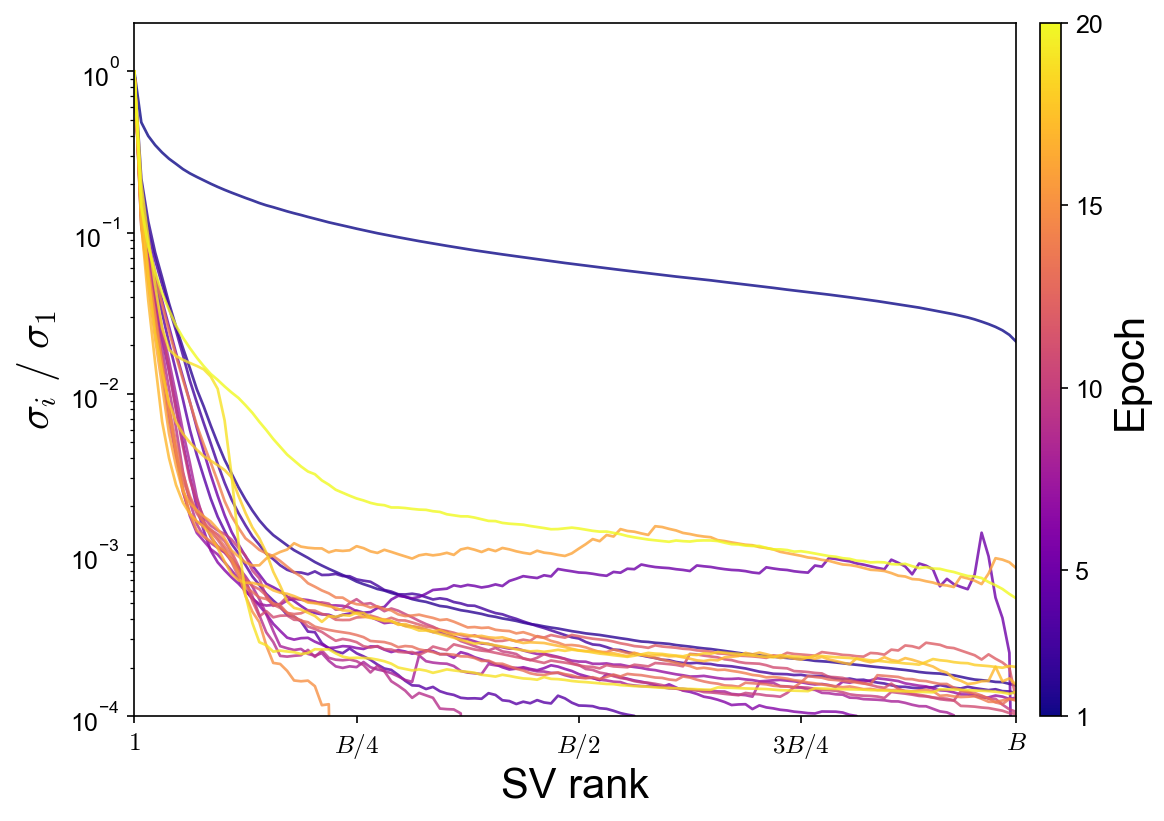

In [20]:

import matplotlib.cm as cm
import matplotlib.colors as mcolors

LR_VIZ    = 1.0
K_VIZ = 128
RTOL_VIZ = 1e-4
EPS_FLOOR = 1e-6

def get_epoch_spectra(df, bs, lr=LR_VIZ, rtol=RTOL_VIZ, k=K_VIZ):
    """Returns (raw spectra, σ_i/σ_1 normalized), shape (n_epoch, k)."""
    sel = df[(df['rtol'] == rtol) & (df['lr'] == lr) & (df['k'] == k)]
    if len(sel) == 0:
        return None, None
    row      = sel.iloc[0]
    svs_raw  = row['svd_info']['svs']
    n_epoch  = len(row['losses']['train'])
    b_per_ep = len(svs_raw) // n_epoch
    k        = int(bs)
    spectra  = np.zeros((n_epoch, k))
    spectra_norm = np.zeros((n_epoch, k))
    for ep in range(n_epoch):
        #arr = np.zeros((b_per_ep, k))
        arr = np.zeros(k)
        arr_norms = np.zeros(k)
        denoms = np.zeros(k)
        for i, sv in enumerate(svs_raw[ep * b_per_ep:(ep + 1) * b_per_ep]):
            arr[:len(sv)] += sv
            arr_norms[:len(sv)] += np.array(sv) / sv[0]
            denoms[:len(sv)] += 1
        arr /= np.maximum(denoms, 1)  # avoid division by zero
        arr_norms /= np.maximum(denoms, 1)
        #for i, sv in enumerate(svs_raw[ep * b_per_ep:(ep + 1) * b_per_ep]):
        #    arr[i, :len(sv)] = sv
        #spectra[ep] = arr.mean(axis=0)
        #spectra[ep] = np.average(arr, axis=0, weights=(arr != 0).astype(float))
        spectra[ep] = arr
        spectra_norm[ep] = arr_norms
    return spectra, spectra_norm

# ── Plot 1: spectral decay lines, colored by training epoch ─────────

cmap_ep = plt.cm.plasma
N_EPOCH  = 20
norm_ep  = mcolors.Normalize(vmin=1, vmax=N_EPOCH)

fig, ax = plt.subplots(1,1,figsize=(8,6))

_, spec_norm = get_epoch_spectra(df_svd, bs, rtol=RTOL_VIZ, lr=LR_VIZ, k=K_VIZ)
n_ep, k      = spec_norm.shape

for ep in range(n_ep):
    sv = np.clip(spec_norm[ep], EPS_FLOOR, 1.0)
    ax.semilogy(np.arange(k), sv,
                color=cmap_ep(norm_ep(ep + 1)), lw=1.3, alpha=0.8)

ax.set_xlabel('SV rank')
ax.set_xlim(0, k - 1)
ax.set_xticks([0, k//4, k//2, 3*k//4, k-1], labels=[f"$1$", f"$B/4$", f"$B/2$", f"$3B/4$", f"$B$"])
ax.set_ylim(1e-4,None)

ax.set_ylabel('$\\sigma_i \\ / \\ \\sigma_1$')

fig.subplots_adjust(right=0.86)
fig.canvas.draw()
pos  = ax.get_position()
cax  = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.017, pos.height])
sm   = cm.ScalarMappable(cmap=cmap_ep, norm=norm_ep)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Epoch')
cbar.set_ticks([1, 5, 10, 15, 20])

#fig.savefig(PLOT_DIR / 'sv_spectra_lines.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)
